# Pytorch

In [1]:
import torch

Tensor is just a type ofe multidimentional array. Same as with numpy there are many methods of constructing a tensor.

In [2]:
data = [[1,2,3], [4,5,6]]
new_tensor = torch.tensor(data)

In [3]:
print(new_tensor)

tensor([[1, 2, 3],
        [4, 5, 6]])


Just like in numpy you can create a tensor of desired shape.

In [4]:
shape = (2,2)

ones = torch.ones(shape)
zeros = torch.zeros(shape)
random_t = torch.randn(shape)

In [5]:
print(f'{ones}\n{zeros}\n{random_t}')

tensor([[1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[0.0776, 1.7367],
        [0.5848, 0.5804]])


Or you can mimic another tensor's properties.

In [6]:
rand_like = torch.randn_like(new_tensor, dtype = torch.float)
rand_like

tensor([[ 2.3100,  0.4265, -0.0069],
        [ 0.6487,  0.1376, -2.8738]])

Every tensor has 3 attributes:

* .shape - Tuple that describes the dimensions of the tensor. For example torch.size([1,2]) tells us that it's a tensor with 1 row and 2 columns. Shape is the most important part in pytorch. 99% of errors are shape mismatches.

*  .device - Tells us where the tensor's data is loaded. CPU or GPU. By default it's CPU

* .dtype - the data type of the tensor. torch.float32 by sefualt, so the standard single precision you'll see all across AI world, The model parameters use this dtype in training (it might change later on n the models lifetume, thrugh quantization and such). It's becasue the changes in gradinet are tiny nudges, like 0.0013.

In [7]:
print(f'Shape: {rand_like.shape}')
print(f'dtype: {rand_like.dtype}')
print(f'device: {rand_like.device}')

Shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu


Model params must be a float type. float32 is the standard. Stuff that learns has to be a float.

# Autograd

automatic diffrentiation. So a pytorch built in gradient calculator.

 You turn it on by setting requires_grad = true, that allows the tensor to learn, otherwise it's just a data tensor. Si it makes the tensor is a learnable parameter now, just like model weights and bias.

In [8]:
data_tensor = torch.tensor([[1,2,3,4], [5,6,7,8]])

w = torch.tensor([[1.0], [2.0]], requires_grad=True)

In [9]:
print(f'Data tensor requires_grad {data_tensor.requires_grad}')
print(f'w tensor requires_grad {w.requires_grad}')

Data tensor requires_grad False
w tensor requires_grad True


## Computational graph

Once requires_grad is true pytorch starts to build a computation graph, so a live recording of all the operations. Everytime an operation happens, be it addition, multiplication, subtraction that requires gradients, pytorch automatically addis at ad a node in the graph.

We're gonna buld a simples graph there is:

Compute

$z = x * y$

$y = a + b$

In [10]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)

In [11]:
y = a + b # first op

In [12]:
z = x * y # second op

You can see that the graph has ben made by looking at the grad_fn attribute/field.

Every tensor that is a result of an operation has a special attrubite called **.grad_fn**, that points to the function that created it.

In [13]:
print(z)
print(f'Grad function for y = {y.grad_fn}')
print(f'Grad function for z = {z.grad_fn}')

tensor(20., grad_fn=<MulBackward0>)
Grad function for y = <AddBackward0 object at 0x7c9948746a10>
Grad function for z = <MulBackward0 object at 0x7c9948746a10>


The graph is used later to calculate the gradients of all the parameters. So we got a complete history of all the operations in our graph.

## Match and Reduction operators.

When it comes to deep learning, theese operations are acctually suprisingly easy


In [14]:
a, b = torch.tensor([[1, 2], [3, 4]]), torch.tensor([[5, 6], [7, 8]])

print(f'result of * operation = {a * b}')
print(f'result of @ operation = {a @ b}')

result of * operation = tensor([[ 5, 12],
        [21, 32]])
result of @ operation = tensor([[19, 22],
        [43, 50]])


It has to follow the matrix mutiplication rules, so the number of rows must equal the number of columns.

In [15]:
print(f'result of @ operation = {torch.tensor([[1, 2, 3], [4, 5, 6]]) @ torch.tensor([[1,2], [3,4], [5,6]])}')

result of @ operation = tensor([[22, 28],
        [49, 64]])


Reduction operations / aggregate functions

In [16]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean()

tensor(3.5000)

The dim arguments let's you decide whitch dimention to collapse.

dim = 0 collapses roes, so it works **vertically** 👇

dim = 1 collapses roes, so it works **horizontally** 👉

In [17]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean(dim=0)

tensor([2.5000, 3.5000, 4.5000])

In [18]:
torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float).mean(dim=1)

tensor([2., 5.])

# Indexing

Basic indexing works the same as numpy indexing.

In [19]:
torch.argmax(torch.tensor([[1, 2, 3], [4, 5, 6]]), dim=1), torch.argmax(torch.tensor([[1, 2, 3], [4, 5, 6]]), dim=0)

(tensor([2, 2]), tensor([1, 1, 1]))

torch.gather = dynamic optimized value selection.

In [20]:
data = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
indicies_to_select = torch.tensor([[0], [1], [2]])

torch.gather(data, dim=1, index=indicies_to_select)

tensor([[1],
        [5],
        [9]])

# Building a model from scratch

We want to implement simple Linear regression.

$ \hat{y} = ax + b$

Let's assume our data follows the line t = 4x + 5

In [21]:
# data batch size
N = 100

# 1 input feature and 1 output
D_in, D_out = 1, 1

X = torch.randn(N, D_in)
X[:10]

tensor([[ 0.3076],
        [-0.4364],
        [ 0.2678],
        [-0.8734],
        [-0.7510],
        [ 1.4540],
        [-0.5234],
        [ 0.1815],
        [-0.6316],
        [ 1.2173]])

In [22]:
true_W, true_b = torch.tensor([[4.0]]), torch.tensor(5.0)
true_W, true_b

(tensor([[4.]]), tensor(5.))

In [23]:
y_true = X @ true_W + true_b + torch.randn(N, D_out) * 0.2 # adding some random noise

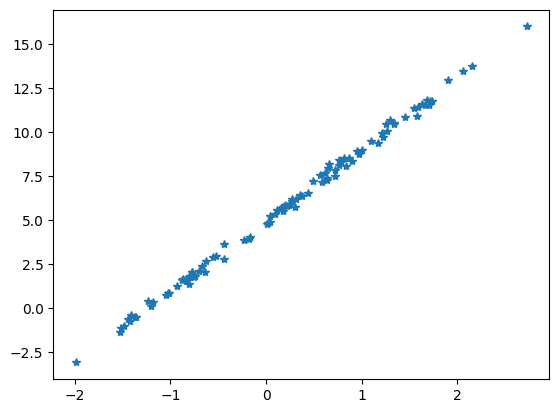

In [24]:
import matplotlib.pyplot as plt

plt.plot(X.detach().numpy(), y_true.detach().numpy(), '*')

In [25]:
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [26]:
print(f'Initial weights = {W}')
print(f'Initial bias = {b}')

Initial weights = tensor([[0.8676]], requires_grad=True)
Initial bias = tensor([-0.3818], requires_grad=True)


Forward pass

In [27]:
y_hat = X @ W + b

In [28]:
print(f'Shape of the prediction y_hat = {y_hat.shape}\n')
print(f'Prediction of the prediction y_hat = {y_hat[:10]}\n')
print(f'true labels = {y_true[:10]}\n')

Shape of the prediction y_hat = torch.Size([100, 1])

Prediction of the prediction y_hat = tensor([[-0.1149],
        [-0.7604],
        [-0.1495],
        [-1.1395],
        [-1.0333],
        [ 0.8797],
        [-0.8358],
        [-0.2243],
        [-0.9297],
        [ 0.6743]], grad_fn=<SliceBackward0>)

true labels = tensor([[ 6.2072],
        [ 3.6662],
        [ 6.2247],
        [ 1.6683],
        [ 1.7806],
        [10.8891],
        [ 2.9776],
        [ 5.5439],
        [ 2.6837],
        [ 9.7186]])



Backward Pass

In [29]:
error = y_hat - y_true
squared_error = error**2
loss = squared_error.mean()

print(f'Loss of our \'model\' = {loss}\n', loss)

Loss of our 'model' = 46.91828918457031
 tensor(46.9183, grad_fn=<MeanBackward0>)


Now we're gonna compute the derivatives of our model.

the torch.tensor.backward() function is gonna compute the gradients for us.

In [30]:
loss.backward()

In [31]:
print(f"Gradient for W (∂L/∂W):\n {W.grad}\n")
print(f"Gradient for b (∂L/∂b):\n {b.grad}")

Gradient for W (∂L/∂W):
 tensor([[-9.2169]])

Gradient for b (∂L/∂b):
 tensor([-12.0097])


Negative gradient = We increase the value and the looss decreases

Positive gradient = We decrease the value and the loss decreases

torch.go_grad = Context-manager that disables gradient calculation

In [32]:
learning_rate = 0.01

epochs = 200

W = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f'Starting the training process\nStarting training params:\nW = {W.item()}\nb = {b.item()}')

for epoch in range(epochs):

  y_hat = X @ W + b
  loss = torch.mean((y_hat - y_true)**2)

  loss.backward()

  with torch.no_grad():
    W -= learning_rate * W.grad
    b -= learning_rate * b.grad

  W.grad.zero_()
  b.grad.zero_()

  if epoch % 10 == 0:
    print(f'Epoch: {epoch}\nLoss: {loss}\nW = {W.item()}\nb = {b.item()}')

print(f'Final parameters = W = {W.item()}\nb = {b.item()}')

Starting the training process
Starting training params:
W = -0.28080081939697266
b = -0.4293181896209717
Epoch: 0
Loss: 59.57308578491211
W = -0.16274398565292358
b = -0.30371516942977905
Epoch: 10
Loss: 35.975128173828125
W = 0.8579812049865723
b = 0.7997214794158936
Epoch: 20
Loss: 21.762714385986328
W = 1.6364632844924927
b = 1.668570637702942
Epoch: 30
Loss: 13.193744659423828
W = 2.229299545288086
b = 2.3535308837890625
Epoch: 40
Loss: 8.020827293395996
W = 2.6799983978271484
b = 2.894205093383789
Epoch: 50
Loss: 4.893465042114258
W = 3.021986484527588
b = 3.3215510845184326
Epoch: 60
Loss: 2.9995532035827637
W = 3.28092622756958
b = 3.659789800643921
Epoch: 70
Loss: 1.8503564596176147
W = 3.4765050411224365
b = 3.927884817123413
Epoch: 80
Loss: 1.1514554023742676
W = 3.6238138675689697
b = 4.140699863433838
Epoch: 90
Loss: 0.7253041863441467
W = 3.7344095706939697
b = 4.309891700744629
Epoch: 100
Loss: 0.4646870493888855
W = 3.817134380340576
b = 4.444616794586182
Epoch: 110
Loss

In [33]:
D_in = 1
D_out = 1

linear_layer = torch.nn.Linear(in_features = D_in, out_features = D_out)

print(f"Layer's weight (W) = {linear_layer.weight}")
print(f"Layer's bias (b) = {linear_layer.bias}")

y_hat_nn = linear_layer(X)
print(f"Output of linear layer = {y_hat_nn[:10]}")

Layer's weight (W) = Parameter containing:
tensor([[0.5243]], requires_grad=True)
Layer's bias (b) = Parameter containing:
tensor([-0.4309], requires_grad=True)
Output of linear layer = tensor([[-0.2697],
        [-0.6598],
        [-0.2905],
        [-0.8889],
        [-0.8247],
        [ 0.3314],
        [-0.7053],
        [-0.3358],
        [-0.7621],
        [ 0.2073]], grad_fn=<SliceBackward0>)


Paarameter is a special kind of tensor that:
*  requires_grad = True by default
*  auto registers with the model
*  Handles all the bookkeeping

In [34]:
relu = torch.nn.ReLU()
sample_data = torch.tensor([-1, -0.5, 1, 2])
activated_data = relu(sample_data)
activated_data

tensor([0., 0., 1., 2.])

In [35]:
relu = torch.nn.GELU()
sample_data = torch.tensor([-1, -0.5, 1, 2])
activated_data = relu(sample_data)
activated_data

tensor([-0.1587, -0.1543,  0.8413,  1.9545])

Softmax -> converts output logits to a propability distribution

In [36]:
softmax = torch.nn.Softmax(dim=1)

logits = torch.Tensor([[1, 2, 3, 4], [-1, -2, 2, 1]])
propas = softmax(logits)

print(f"Output propas: {propas}")
print(f"Sum of logits = {propas[0].sum()}")

Output propas: tensor([[0.0321, 0.0871, 0.2369, 0.6439],
        [0.0347, 0.0128, 0.6964, 0.2562]])
Sum of logits = 1.0


In [37]:
vocab_size = 10
embedding_dim = 5

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

input_ids = torch.tensor([[1, 5, 0, 8]])
word_vectors = embedding_layer(input_ids)
print(word_vectors)

tensor([[[ 0.6976, -0.6106, -1.6005,  0.9526, -2.1679],
         [ 0.1104, -2.0775, -0.6657, -0.6256, -0.1828],
         [-0.8700,  0.1227, -1.4367, -0.4948, -1.3659],
         [-1.1509,  0.4115, -0.8650, -0.1868, -0.1611]]],
       grad_fn=<EmbeddingBackward0>)


nn.layernorm - rescales everything to a stable range

In [38]:
norm_layer = torch.nn.LayerNorm(normalized_shape=5)
input_features = torch.tensor([[[1.0, 2.0, 3.0, 4.0, 5.0], [4.0, 5.0, 6.0, 7.0, 8.0]]])
normalized_features = norm_layer(input_features)

In [39]:
print(f"Mean of normalized features = {normalized_features.mean(dim=-1)}")
print(f"Std of normalized features = {normalized_features.std(dim=-1)}")

Mean of normalized features = tensor([[0., 0.]], grad_fn=<MeanBackward1>)
Std of normalized features = tensor([[1.1180, 1.1180]], grad_fn=<StdBackward0>)


nn.dropout - randomly zeros out part of the neurons. Forces the network to utilize all of its neurons, and not rely only on a few strong ones

In [40]:
dropout_layer = torch.nn.Dropout(p=0.5)
input_tensor = torch.ones(1, 10)

dropout_layer.train()
output_during_training = dropout_layer(input_tensor)

dropout_layer.eval()
output_during_inference = dropout_layer(input_tensor)

print(f"Dropout output during training = {output_during_training}")
print(f"Dropout output during inference / eval = {output_during_inference}")

Dropout output during training = tensor([[2., 2., 0., 0., 0., 0., 0., 2., 0., 0.]])
Dropout output during inference / eval = tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


nn.Module - organizes the module


tortch.Optim - optimizer, knows how to adjust the layers

In [41]:
class LinRegModel(torch.nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()
    self.linear_layer = torch.nn.Linear(in_features, out_features)

  def forward(self, x):
    return self.linear_layer(x)

model = LinRegModel(in_features=1, out_features=1)

In [42]:
print(model)

LinRegModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


In [43]:
learning_rate = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.Muon

loss_fn = torch.nn.MSELoss()

Essential 3 lines, the trainign process

In [44]:
epochs = 500

for epoch in range(epochs):
  y_hat = model(X)

  loss = loss_fn(y_hat, y_true)

  # Zero the gradients
  optimizer.zero_grad()
  # Compute gradinets
  loss.backward()
  # update the parameters
  optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch {epoch} Loss = {loss.item()}")

Epoch 0 Loss = 46.9320182800293
Epoch 10 Loss = 44.808502197265625
Epoch 20 Loss = 42.743743896484375
Epoch 30 Loss = 40.74370193481445
Epoch 40 Loss = 38.81172180175781
Epoch 50 Loss = 36.94901657104492
Epoch 60 Loss = 35.15536880493164
Epoch 70 Loss = 33.429813385009766
Epoch 80 Loss = 31.7710018157959
Epoch 90 Loss = 30.17740249633789
Epoch 100 Loss = 28.647436141967773
Epoch 110 Loss = 27.179479598999023
Epoch 120 Loss = 25.77191162109375
Epoch 130 Loss = 24.423107147216797
Epoch 140 Loss = 23.131446838378906
Epoch 150 Loss = 21.89531898498535
Epoch 160 Loss = 20.713123321533203
Epoch 170 Loss = 19.583255767822266
Epoch 180 Loss = 18.504140853881836
Epoch 190 Loss = 17.474201202392578
Epoch 200 Loss = 16.49187469482422
Epoch 210 Loss = 15.555612564086914
Epoch 220 Loss = 14.663891792297363
Epoch 230 Loss = 13.815190315246582
Epoch 240 Loss = 13.008013725280762
Epoch 250 Loss = 12.240882873535156
Epoch 260 Loss = 11.512332916259766
Epoch 270 Loss = 10.820937156677246
Epoch 280 Loss 